In [6]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from keras.preprocessing.image import ImageDataGenerator
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

In [7]:
test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.mobilenet.preprocess_input).flow_from_directory('C:\\Users\\Dell\\Desktop\\Dataset\\Test', target_size=(224,224), batch_size=32,
        classes = ['BabyCry', 'Bark', 'Cough', 'Dishes', 'Doorbell', 'FireAlarm', 'SmokeDetector', 'Sneeze', 'Thunder', 'Water'], shuffle = False)
model2 = load_model("D:\\SavedModels\\MNLatest.h5")
predictions = model2.predict(x = test_batches, verbose = 1)

Found 524 images belonging to 10 classes.
17/17 [==============================] - 10s 552ms/step


In [8]:
accuracy = metrics.accuracy_score(test_batches.classes, np.argmax(predictions, axis = -1))
recall = metrics.recall_score(test_batches.classes, np.argmax(predictions, axis = -1), average='macro')
precision = metrics.precision_score(test_batches.classes, np.argmax(predictions, axis = -1), average='macro')
f1_score = metrics.f1_score(test_batches.classes, np.argmax(predictions, axis = -1), average='macro')
                    
print("Accuracy: %.3f" % accuracy)
print('Recall: %.3f' % recall)
print('Precision: %.3f' % precision)
print('F1 Score: %.3f' % f1_score)

Accuracy: 0.903
Recall: 0.905
Precision: 0.908
F1 Score: 0.892


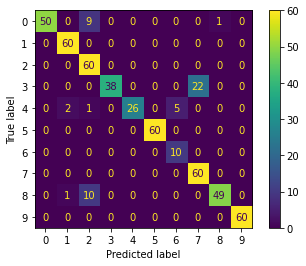

In [14]:
confusion_matrix = metrics.confusion_matrix(test_batches.classes, np.argmax(predictions, axis = -1))
display = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
display.plot()